In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import CubicSpline


In [21]:
df=pd.read_csv('task for muda/International Energy Agency - Nigeria Crude oil imports and exports.csv')

In [22]:
df.head(30)

,"crude oil, Nigeria",Value,Year,Units
0,Exports,-4701528,2000,TJ
1,Exports,-4647496,2001,TJ
2,Exports,-3988808,2002,TJ
3,Exports,-4767017,2003,TJ
4,Exports,-5266601,2004,TJ
5,Exports,-5074667,2005,TJ
6,Exports,-4936722,2006,TJ
7,Exports,-4816902,2007,TJ
8,Exports,-4416278,2008,TJ
9,Exports,-4615137,2009,TJ


In [23]:
# 1. Prepare Data from the image
years = np.array([
    2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 
    2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 
    2020, 2021, 2022, 2023
])

exports = np.array([
    -4701528, -4647496, -3388808, -4767017, -5266601, -5074667, 
    -4936722, -4816902, -4416278, -4615137, -5229368, -4987377, 
    -5059534, -4472575, -4542851, -4524342, -3779860, -3806306, 
    -3985855, -4219844, -3228631, -2704766, -2395988, -2664570
])


In [24]:
# Generate a continuous smooth range of years for visualization curves
years_smooth = np.linspace(years.min(), years.max(), 500)


In [25]:
# 2. Polynomial Least-Squares Regression (Example: 3rd degree polynomial)
# You can adjust the degree integer (e.g., 2, 3, 4) depending on your required order
poly_degree = 3
poly_coefficients = np.polyfit(years, exports, poly_degree)
poly_function = np.poly1d(poly_coefficients)
exports_poly_smooth = poly_function(years_smooth)


In [26]:
# 3. Cubic Spline Interpolation
# This forces a smooth curve directly through every single exact data point
cubic_spline = CubicSpline(years, exports)
exports_spline_smooth = cubic_spline(years_smooth)


In [27]:
# --- Print Results / Coefficients ---
print("--- Polynomial Regression ---")
print(f"Polynomial Coefficients (Degree {poly_degree}):")
print(poly_coefficients)



--- Polynomial Regression ---
Polynomial Coefficients (Degree 3):
[ 1.40582912e+02 -8.37533290e+05  1.66301434e+09 -1.10056318e+12]


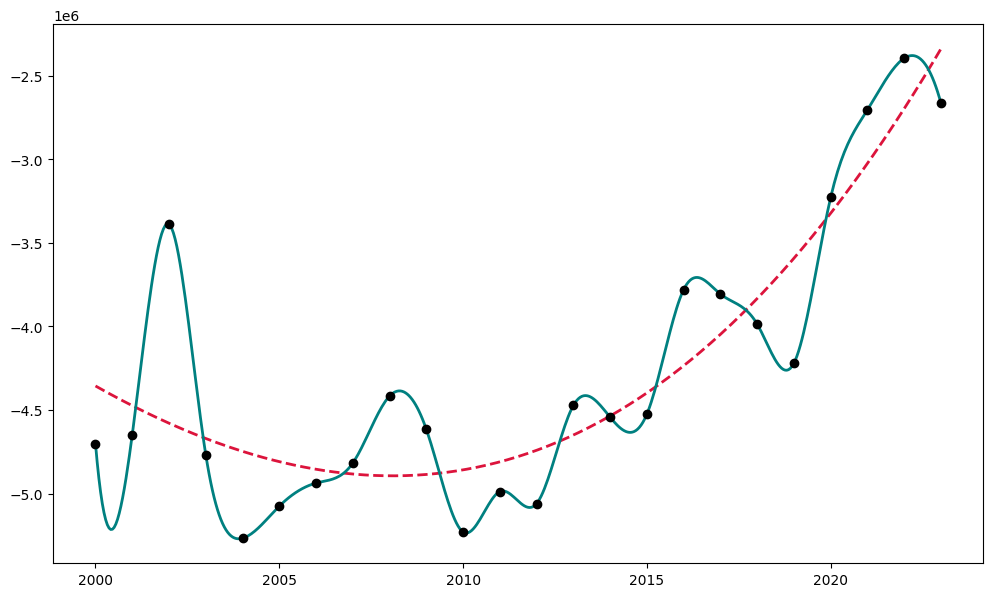

In [28]:
# --- Visualization ---
plt.figure(figsize=(12, 7))
plt.scatter(years, exports, color='black', label='Actual Data Points', zorder=5)
plt.plot(years_smooth, exports_poly_smooth, color='crimson', linestyle='--', linewidth=2, label=f'{poly_degree}-Degree Poly Regression')
plt.plot(years_smooth, exports_spline_smooth, color='teal', linewidth=2, label='Cubic Spline Interpolation')


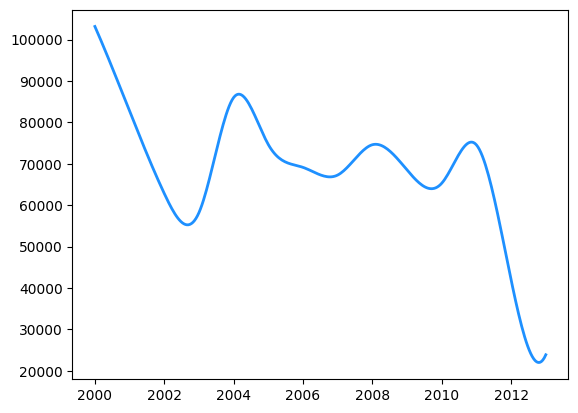

In [16]:
# Plot Cubic Spline
plt.plot(years_smooth, values_spline, label="Cubic Spline Interpolation", color="dodgerblue", linewidth=2)


C:\Users\USER\AppData\Local\Temp\ipykernel_11356\897683584.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=11)


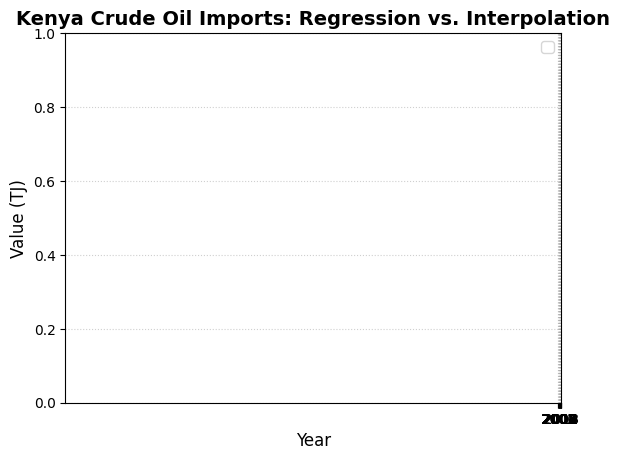

In [20]:
# Customizing the graph
plt.title("Kenya Crude Oil Imports: Regression vs. Interpolation", fontsize=14, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Value (TJ)", fontsize=12)
plt.xticks(years) # Show every year on x-axis
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)


In [18]:
# Display the plot
plt.tight_layout()
plt.show()



<Figure size 640x480 with 0 Axes>